# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Station

In [12]:
snap = station.snapshot(update=True) # <- updates parameters in station

In [13]:
verticalsnap = snap['instruments']['mso5']['submodules']['channels']['channels']['mso5_ch1']['parameters'].keys()

In [14]:
horizontalsnap = snap['instruments']['mso5']['parameters'].keys()

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import osc_set_standard, osc_check_standard, capture_trace
from functions import photon_number
import snspd
params = snspd.snspd()

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260427-22028-qcodes.log
Experiment loaded. Last ID no: 615


# Trace Captures

From the first range of IDs in the dataset 489 - 552

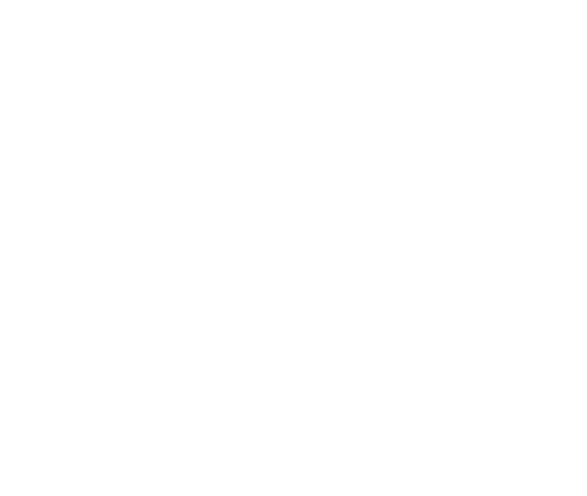

In [5]:
ID = 489
data = load_by_id(ID).get_parameter_data()
trace = data['trace']['trace']
time_axis = data['time_axis']['time_axis']
current = data['yoko_current']['yoko_current'][0]
conditions = 'Dark Counts: Box closed, fibre input to fridge covered'

plt.plot(time_axis, trace)
plt.title(params.make_title(f'Trace Capture {current}uA', ID = ID, extra = conditions))
plt.ylabel('V')
plt.xlabel('Time (s)')
plt.ylim([-0.06, 0.03])
plt.show()

In [4]:
from ipywidgets import interact, IntSlider
import snspd 
params = snspd.snspd()

min_id = 489
max_id = 520


def plot_trace(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    time_axis = data['time_axis']['time_axis']
    current = data['yoko_current']['yoko_current'][0]
    conditions = 'Dark Counts: Box closed, fibre input to fridge covered'

    plt.plot(time_axis, trace)
    plt.title(params.make_title(f'Trace Capture {current}uA', ID = ID, extra = conditions))
    plt.ylabel('V')
    plt.xlabel('Time (s)')
    plt.ylim([-0.06, 0.03])
    plt.show()

interact(plot_trace, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));


interactive(children=(IntSlider(value=489, continuous_update=False, description='ID', max=520, min=489), Outpu…

In [3]:
from ipywidgets import interact, IntSlider
import snspd 
params = snspd.snspd()

min_id = 554
max_id = 580
# max_id = 615


def plot_trace(ID):
    data = load_by_id(ID).get_parameter_data()
    trace = data['trace']['trace']
    time_axis = data['time_axis']['time_axis']
    v_attenuator = data['v_attenuator']['v_attenuator'][0]
    conditions = 'Box closed, fibre input to fridge covered'

    data = load_by_id(params.att_info_id).get_parameter_data()
    idx = np.isclose(data['v_attenuator']['v_attenuator'], v_attenuator, rtol=0.0025).nonzero()[0]
    total_attenuation = float(data['total_attenuation']['total_attenuation'][idx][0])
    Nphotons = float(data['Nphotons']['Nphotons'][idx][0])
    plt.plot(time_axis, trace)
    plt.title(
        f'Voltage on attenuator {v_attenuator} V ID {ID}\n'
        f'({total_attenuation:.1f} dB total, {Nphotons*1e-3:.2f}e3 photons/sec Expected)\n'
        f' \n{conditions}'
    )
    plt.ylabel('V')
    plt.xlabel('Time (s)')
    plt.ylim([-0.06, 0.03])
    plt.show()

interact(plot_trace, ID=IntSlider(min=min_id, max=max_id, step=1, value=min_id,
                                  continuous_update=False));



interactive(children=(IntSlider(value=554, continuous_update=False, description='ID', max=580, min=554), Outpu…